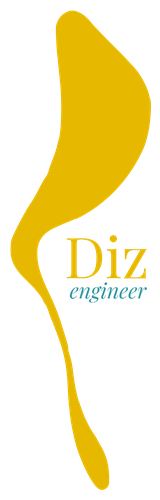

# 🦙 Curso Personalizado: Domina llama.cpp

> Basado en el video "The Best Way to Take Control of Your Local AI Model (llama.cpp)" por William Ruider

---

## 📚 Tabla de Contenidos
1. Introducción
2. ¿Por qué llama.cpp?
3. Instalación según tu sistema
4. Parámetros fundamentales
5. Adaptación a tu hardware
6. Configuraciones avanzadas
7. Servidor API compatible con OpenAI
8. Ejercicios prácticos
9. Troubleshooting y mejores prácticas

## 1️⃣ Introducción

### ¿Qué es llama.cpp?

Motor de inferencia de LLM escrito en C/C++ que permite ejecutar modelos de IA localmente con rendimiento state-of-the-art.

### Diferencia con Ollama

- **Ollama**: Aplicación de alto nivel que usa llama.cpp como motor base
- **llama.cpp**: Motor de bajo nivel con control TOTAL sobre la inferencia
- **Ventaja**: Acceso a todos los parámetros y optimizaciones que Ollama oculta

## 2️⃣ ¿Por qué usar llama.cpp?

### Ventajas principales:

✅ **Control total** sobre todos los parámetros de inferencia
✅ **Acceso completo** a samplers avanzados
✅ **Optimizaciones específicas** para tu hardware
✅ **Rendimiento máximo** al eliminar overhead
✅ **Compatibilidad** con GGUF de Hugging Face
✅ **API REST** compatible con OpenAI

| Escenario | Recomendación |
|-----------|---------------|
| Pruebas rápidas | Ollama |
| Control fino de parámetros | llama.cpp |
| Máximo rendimiento en GPU | llama.cpp |
| Desarrollo de aplicaciones | llama.cpp |

In [ ]:
import platform
import psutil
import subprocess

print(f"🖥️ Sistema Operativo: {platform.system()} {platform.release()}")
print(f"💻 Arquitectura: {platform.machine()}")
print(f"🧠 CPU: {platform.processor()}")
print(f"💾 RAM Total: {round(psutil.virtual_memory().total / (1024**3), 2)} GB")

try:
    gpu_info = subprocess.check_output(
        ['nvidia-smi', '--query-gpu=name,memory.total,memory.free,memory.used,driver_version',
         '--format=csv,noheader'],
        text=True,
    ).strip()
    name, vram_total, vram_free, vram_used, driver = [x.strip() for x in gpu_info.split(',')]
    print(f"🎮 GPU NVIDIA detectada: {name}")
    print(f"   💾 VRAM Total (memoria dedicada): {vram_total}")
    print(f"   📊 VRAM en uso: {vram_used}")
    print(f"   ✅ VRAM libre: {vram_free}")
    print(f"   🔧 Driver: {driver}")
except FileNotFoundError:
    print("❌ GPU NVIDIA no detectada (nvidia-smi no está instalado)")
except Exception:
    print("❌ GPU NVIDIA no detectada")

## 3️⃣ Instalación según tu Sistema

### Opción 1: Binarios Pre-compilados (Más fácil)

Visita https://llama.app para descargar binarios pre-compilados.

### Opción 2: Compilación desde código (Recomendado)

#### 🐧 Linux / WSL2

```bash
sudo apt-get update
sudo apt-get install build-essential cmake git
git clone https://github.com/ggml-org/llama.cpp
cd llama.cpp

# Compilar para CPU
cmake -B build
cmake --build build --config Release

# Compilar para NVIDIA GPU (CUDA)
cmake -B build -DGGML_CUDA=1
cmake --build build --config Release

# Compilar para AMD GPU (ROCm)
cmake -B build -DGGML_HIP=1
cmake --build build --config Release
```

#### 🍎 macOS

```bash
brew install cmake git
git clone https://github.com/ggml-org/llama.cpp
cd llama.cpp
cmake -B build -DGGML_METAL=1
cmake --build build --config Release
```

#### 🪟 Windows (PowerShell)

```powershell
git clone https://github.com/ggml-org/llama.cpp
cd llama.cpp
cmake -B build
cmake --build build --config Release

# Para NVIDIA GPU
cmake -B build -DGGML_CUDA=1
cmake --build build --config Release
```

## 4️⃣ Los 5 Parámetros Más Importantes

### 1. `-ngl` / `--n-gpu-layers` ⚡ (MÁXIMO IMPACTO: 1.3x-2x más rápido)

**Qué hace:** Descarga capas del modelo a la GPU

```bash
# Para GPU completa (RECOMENDADO si tienes GPU)
./llama-cli -ngl 999

# Valor específico según tu GPU VRAM
./llama-cli -ngl 35
```

### 2. `--cache-type-k` y `--cache-type-v` 💾 (AHORRO DE MEMORIA)

**Qué hace:** Controla el tipo de caché KV

```bash
--cache-type-k q8_0 --cache-type-v q8_0  # Mejor calidad
--cache-type-k q4_0 --cache-type-v q4_0  # Balance
```

### 3. `-c` / `--ctx-size` 📏 (CONTEXTO)

**Qué hace:** Define el tamaño del contexto (tokens)

```bash
./llama-cli -c 2048   # Estándar
./llama-cli -c 4096   # Largo
./llama-cli -c 8192   # Muy largo
```

### 4. `-t` / `--threads` 🧵 (HILOS DE CPU)

**Qué hace:** Número de hilos de CPU

```bash
./llama-cli -t $(nproc)  # Linux
./llama-cli -t 8
```

### 5. `-fa` / `--flash-attn` ⚡ (ATENCIÓN FLASH)

**Qué hace:** Habilita Flash Attention

```bash
./llama-cli -fa  # SIEMPRE habilitar
```

In [ ]:
# Calcula cuántas capas puedes descargar a GPU
vram_gb = float(input("¿Cuánta VRAM tiene tu GPU en GB? "))
model_size = float(input("¿Tamaño del modelo en GB? "))

if vram_gb >= model_size * 0.8:
    print("✅ Puedes usar -ngl 999 (GPU completa)")
elif vram_gb >= model_size * 0.5:
    print(f"⚠️ Usa aproximadamente -ngl {int(vram_gb / model_size * 100)}")
else:
    print("❌ Mejor usa CPU o modelo más pequeño")

In [ ]:
import psutil

ram_gb = psutil.virtual_memory().total / (1024**3)

if ram_gb >= 32:
    print("✅ Usa: --cache-type-k q8_0 --cache-type-v q8_0")
elif ram_gb >= 16:
    print("✅ Usa: --cache-type-k q4_0 --cache-type-v q4_0")
else:
    print("⚠️ Usa: --cache-type-k q4_0 --cache-type-v q4_0")

In [ ]:
import multiprocessing

cores_logicos = multiprocessing.cpu_count()
cores_fisicos = cores_logicos // 2

print(f"Núcleos lógicos: {cores_logicos}")
print(f"Núcleos físicos estimados: {cores_fisicos}")
print(f"\n✅ Recomendación: usa -t {cores_fisicos}")

## 5️⃣ Adaptación a tu Hardware

### 🖥️ Solo CPU (Sin GPU dedicada)

```bash
./llama-cli \
    -m modelo.gguf \
    -t $(nproc) \
    -c 2048 \
    --cache-type-k q4_0 --cache-type-v q4_0 \
    -fa \
    --no-mmap
```

### 🎮 Con GPU NVIDIA (CUDA)

```bash
./llama-cli \
    -m modelo.gguf \
    -ngl 999 \
    -t 4 \
    -c 4096 \
    --cache-type-k q8_0 --cache-type-v q8_0 \
    -fa \
    --temp 0.7
```

### 🍎 Apple Silicon (M1/M2/M3/M4)

```bash
./llama-cli \
    -m modelo.gguf \
    -ngl 999 \
    -t 8 \
    -c 4096 \
    --cache-type-k q8_0 --cache-type-v q8_0 \
    -fa
```

**Optimización específica macOS:**
```bash
sudo sysctl iogpu.wired_lwm_mb=128000
```

## 6️⃣ Configuraciones Avanzadas

### 🎛️ Parámetros de Muestreo (Samplers)

```bash
./llama-cli \
    -m modelo.gguf \
    --temp 0.7 \           # Temperatura (0.0-2.0)
    --top-k 40 \           # Top-K sampling
    --top-p 0.9 \          # Top-P (nucleus) sampling
    --min-p 0.05 \         # Min-P sampling
    --repeat-penalty 1.1   # Penalización de repeticiones
```

**Guía de temperaturas:**
- `0.0-0.3`: Muy determinista (código, matemáticas)
- `0.4-0.7`: Balance general (conversación)
- `0.8-1.0`: Creativo (escritura)
- `1.1-1.5`: Muy creativo (brainstorming)
- `1.6-2.0`: Experimental (muy aleatorio)

In [ ]:
configs = {
    "codigo": {
        "temp": 0.2,
        "top_k": 10,
        "top_p": 0.95,
        "repeat_penalty": 1.0,
        "uso": "Programación, código técnico"
    },
    "conversacion": {
        "temp": 0.7,
        "top_k": 40,
        "top_p": 0.9,
        "repeat_penalty": 1.1,
        "uso": "Chat general, asistencia"
    },
    "creativo": {
        "temp": 0.9,
        "top_k": 100,
        "top_p": 0.95,
        "repeat_penalty": 1.2,
        "uso": "Escritura creativa, historias"
    },
    "tecnico": {
        "temp": 0.3,
        "top_k": 20,
        "top_p": 0.85,
        "repeat_penalty": 1.05,
        "uso": "Análisis técnico, documentos"
    }
}

print("📋 Configuraciones Predefinidas:")
for nombre, config in configs.items():
    print(f"\n🎯 {nombre.upper()} - {config['uso']}")
    print(f"   --temp {config['temp']} --top-k {config['top_k']} --top-p {config['top_p']} --repeat-penalty {config['repeat_penalty']}")

## 7️⃣ Servidor API Compatible con OpenAI

### Iniciar llama-server

```bash
# Servidor básico
./llama-server \
    -m modelo.gguf \
    --host 0.0.0.0 \
    --port 8080 \
    -ngl 999 \
    -c 4096

# Servidor optimizado para producción
./llama-server \
    -m modelo.gguf \
    --host 127.0.0.1 \
    --port 8080 \
    -ngl 999 \
    -c 8192 \
    -t 8 \
    -fa \
    --cache-type-k q8_0 \
    --cache-type-v q8_0 \
    --timeout 600
```

In [ ]:
import requests
import json

# Endpoint compatible con OpenAI
url = "http://localhost:8080/v1/chat/completions"

headers = {"Content-Type": "application/json"}

data = {
    "messages": [
        {"role": "system", "content": "Eres un asistente útil."},
        {"role": "user", "content": "¿Qué es llama.cpp?"}
    ],
    "temperature": 0.7,
    "max_tokens": 500
}

# response = requests.post(url, headers=headers, json=data)
# print(json.dumps(response.json(), indent=2, ensure_ascii=False))
print("⚠️ Descomenta las líneas anteriores cuando tengas el servidor corriendo")

In [ ]:
from openai import OpenAI

# Configurar cliente OpenAI para usar llama.cpp
client = OpenAI(
    base_url="http://localhost:8080/v1",
    api_key="not-needed"  # llama.cpp no requiere API key
)

# response = client.chat.completions.create(
#     model="local-model",
#     messages=[
#         {"role": "system", "content": "Eres un asistente útil."},
#         {"role": "user", "content": "Explica qué es llama.cpp"}
#     ],
#     temperature=0.7,
#     max_tokens=500
# )

# print(response.choices[0].message.content)
print("⚠️ Descomenta las líneas anteriores cuando tengas el servidor corriendo")

## 8️⃣ Ejercicios Prácticos

### 🎯 Ejercicio 1: Tu Primera Inferencia

**Objetivo:** Ejecutar tu primer modelo con llama.cpp

```bash
# 1. Descarga un modelo GGUF desde Hugging Face
# Ejemplo: Qwen2.5-7B-Instruct

# 2. Ejecuta con configuración básica
./llama-cli \
    -m qwen2.5-7b-instruct-q4_k_m.gguf \
    -p "¿Qué es la inteligencia artificial?" \
    -n 200 \
    -c 2048

# 3. Ahora prueba con tu configuración optimizada
./llama-cli \
    -m qwen2.5-7b-instruct-q4_k_m.gguf \
    -p "Explica la computación cuántica" \
    -n 500 \
    -ngl 999 \
    -t $(nproc) \
    -c 4096 \
    -fa \
    --temp 0.7
```

### 🎯 Ejercicio 2: Chat Interactivo

```bash
./llama-cli \
    -m modelo.gguf \
    -ngl 999 \
    -c 4096 \
    --chatml \
    -i \
    --in-prefix " " \
    --in-suffix " " \
    --temp 0.7
```

## 9️⃣ Troubleshooting y Mejores Prácticas

### ❌ Problemas Comunes

#### 1. "Out of Memory" en GPU

```bash
# Solución 1: Reducir capas en GPU
./llama-cli -ngl 25  # En lugar de 999

# Solución 2: Reducir contexto
./llama-cli -c 2048  # En lugar de 8192

# Solución 3: Usar quantización más agresiva
./llama-cli --cache-type-k q4_0 --cache-type-v q4_0

# Solución 4: Usar modelo más pequeño
# Cambiar de 13B a 7B, o de Q5 a Q4
```

#### 2. Inferencia muy lenta en CPU

```bash
# Solución 1: Aumentar hilos
./llama-cli -t $(nproc)

# Solución 2: Habilitar flash attention
./llama-cli -fa

# Solución 3: Reducir contexto
./llama-cli -c 2048

# Solución 4: Usar modelo quantizado más pequeño
# Ejemplo: Q4_K_M en lugar de Q5_K_M
```

### ✅ Mejores Prácticas

1. **Siempre usa `-fa` (Flash Attention)** si está disponible
2. **Maximiza `-ngl`** para descargar más capas a GPU
3. **Usa el tipo de caché apropiado** según tu RAM
4. **Ajusta el contexto** según tus necesidades reales
5. **Mantén modelos organizados** en carpetas
6. **Documenta tus configuraciones** exitosas
7. **Actualiza llama.cpp** regularmente
8. **Prueba diferentes cuantizaciones** (Q4_K_M es buen balance)

In [ ]:
casos_uso = {
    "desarrollo": {
        "modelo": "Qwen2.5-Coder-7B-Instruct-Q5_K_M.gguf",
        "config": "-ngl 999 -t 8 -c 8192 -fa --temp 0.2 --top-k 10",
        "descripcion": "Programación y desarrollo de software"
    },
    "asistente": {
        "modelo": "Qwen2.5-7B-Instruct-Q5_K_M.gguf",
        "config": "-ngl 999 -t 8 -c 4096 -fa --temp 0.7 --top-k 40",
        "descripcion": "Asistente general y conversación"
    },
    "creativo": {
        "modelo": "Llama-3.1-8B-Instruct-Q5_K_M.gguf",
        "config": "-ngl 999 -t 8 -c 8192 -fa --temp 0.9 --top-k 100",
        "descripcion": "Escritura creativa y brainstorming"
    },
    "analisis": {
        "modelo": "Qwen2.5-14B-Instruct-Q4_K_M.gguf",
        "config": "-ngl 999 -t 8 -c 16384 -fa --temp 0.3 --top-k 20",
        "descripcion": "Análisis de documentos largos"
    }
}

print("🎯 Configuraciones Recomendadas por Caso de Uso:")
print("=" * 70)
for caso, detalles in casos_uso.items():
    print(f"\n📌 {caso.upper()}: {detalles['descripcion']}")
    print(f"   Modelo: {detalles['modelo']}")
    print(f"   Config: {detalles['config']}")

## 🎓 Recursos Adicionales

### Enlaces útiles:
- 📖 **Documentación oficial:** https://github.com/ggml-org/llama.cpp
- 🤗 **Modelos GGUF:** https://huggingface.co/models?sort=trending&search=gguf
- 🛠️ **Binarios pre-compilados:** https://llama.app
- 💬 **Discord comunidad:** Buscar "llama.cpp Discord"

### Comandos útiles de diagnóstico:

```bash
# Ver información del modelo
./llama-cli -m modelo.gguf --help

# Ver uso de recursos
htop  # Linux/macOS
top   # Alternativa

# Monitorear GPU NVIDIA
watch -n 1 nvidia-smi

# Ver logs del servidor
journalctl -u llama-server -f
```

## 🎉 Conclusión

¡Felicidades! Ahora tienes el conocimiento para:

✅ Instalar llama.cpp en cualquier sistema
✅ Configurar parámetros óptimos para tu hardware
✅ Aprovechar al máximo tu GPU o CPU
✅ Crear tu propio servidor API compatible con OpenAI
✅ Realizar benchmarks y optimizaciones
✅ Solucionar problemas comunes

**Recuerda:** La clave está en experimentar con diferentes configuraciones y encontrar el balance perfecto entre rendimiento, calidad y velocidad para tu caso de uso específico.

---

## 📝 Tu Checklist de Configuración:

- [ ] Detecté mi sistema operativo y hardware
- [ ] Instalé llama.cpp correctamente
- [ ] Identifiqué cuánta VRAM/RAM tengo disponible
- [ ] Configuré `-ngl` apropiadamente para mi GPU
- [ ] Ajusté el contexto según mis necesidades
- [ ] Habilité Flash Attention (`-fa`)
- [ ] Probé diferentes temperaturas para mis casos de uso
- [ ] Configuré el servidor API (opcional)
- [ ] Documenté mi configuración óptima

---

**Creado como curso personalizado basado en:** "The Best Way to Take Control of Your Local AI Model (llama.cpp)" por William Ruider

**Adaptado a tu sistema con:** Configuraciones específicas para CPU, GPU NVIDIA, Apple Silicon y más

**Versión:** 1.0  
**Fecha:** Agosto 2026

---

# 🚀 PARTE 2: Configuraciones Técnicas Avanzadas

> Ampliación de la Parte 1. Esta parte profundiza en la compilación optimizada, los parámetros técnicos críticos, la configuración de KV Cache, los samplers avanzados (DRY, Dynamic Temperature, XTC), los servidores de producción y el diagnóstico de rendimiento.

## 📚 Contenidos de la Parte 2
1. Compilación avanzada y optimizaciones
2. Parámetros técnicos críticos
3. Configuración de KV Cache
4. Samplers avanzados (DRY, Dynamic Temperature, XTC)
5. Ejercicio práctico: Sistema de producción
6. Comandos fundamentales de diagnóstico
7. Optimización por caso de uso
8. Checklist avanzado de configuración


## 1️⃣ Compilación Avanzada y Optimizaciones

### Flags de compilación críticos

#### Para NVIDIA GPU (CUDA)
```bash
# Compilación optimizada para arquitectura específica
cmake -B build \
  -DGGML_CUDA=1 \
  -DCMAKE_CUDA_ARCHITECTURES="80;86" \  # RTX 30/40 series
  -DGGML_CUDA_F16=ON \                  # FP16 para mejor rendimiento
  -DGGML_CUDA_DMMV_X=64 \              # Tamaño de bloque
  -DGGML_CUDA_MMV_Y=2

cmake --build build --config Release -j$(nproc)
```

**Arquitecturas CUDA comunes:**
- RTX 20xx: `75`
- RTX 30xx: `86`
- RTX 40xx: `89`
- A100/H100: `80;90`

#### Para Apple Silicon (Metal)
```bash
cmake -B build \
  -DGGML_METAL=1 \
  -DGGML_METAL_USE_BF16=ON \           # BFloat16
  -DGGML_METAL_NDEBUG=OFF \            # Deshabilitar debug
  -DCMAKE_BUILD_TYPE=Release

cmake --build build --config Release -j$(sysctl -n hw.ncpu)
```

#### Para CPU (AVX2/AVX-512)
```bash
# Detectar capacidades CPU
lscpu | grep -i avx

# Compilar con AVX2
cmake -B build \
  -DGGML_AVX2=ON \
  -DGGML_F16C=ON \
  -DGGML_FMA=ON

# Compilar con AVX-512 (si está disponible)
cmake -B build \
  -DGGML_AVX512=ON \
  -DGGML_AVX512_VBMI=ON \
  -DGGML_AVX512_VNNI=ON
```

In [ ]:
import subprocess
import platform

# Detectar capacidades de CPU
print("🔍 Detectando capacidades de CPU...\n")

if platform.system() == "Linux":
    try:
        cpu_flags = subprocess.check_output(['lscpu'], text=True)
        flags_line = [line for line in cpu_flags.split('\n') if 'Flags:' in line][0]
        
        capabilities = {
            'AVX2': 'avx2' in flags_line,
            'AVX-512': 'avx512' in flags_line,
            'F16C': 'f16c' in flags_line,
            'FMA': 'fma' in flags_line,
            'AVX-VNNI': 'avxvnni' in flags_line
        }
        
        print("Capacidades detectadas:")
        for cap, available in capabilities.items():
            status = "✅" if available else "❌"
            print(f"  {status} {cap}")
        
        print("\n📋 Flags de compilación recomendados:")
        compile_flags = []
        if capabilities['AVX2']:
            compile_flags.append("-DGGML_AVX2=ON")
        if capabilities['AVX-512']:
            compile_flags.append("-DGGML_AVX512=ON")
        if capabilities['F16C']:
            compile_flags.append("-DGGML_F16C=ON")
        if capabilities['FMA']:
            compile_flags.append("-DGGML_FMA=ON")
        
        print(f"cmake -B build {' '.join(compile_flags)}")
        
    except Exception as e:
        print(f"Error detectando CPU: {e}")
        
elif platform.system() == "Darwin":
    print("✅ macOS detectado - Usar: -DGGML_METAL=1")
else:
    print("⚠️ Sistema no reconocido")

## 2️⃣ Parámetros Técnicos Críticos

### Parámetros de memoria y rendimiento

#### `--no-mmap` vs `--mmap`
```bash
# Deshabilitar memory mapping (mejor para SSD rápidos)
./llama-cli --no-mmap -m modelo.gguf

# Habilitar memory mapping (mejor para HDD o RAM limitada)
./llama-cli --mmap -m modelo.gguf
```

**Cuándo usar cada uno:**
- `--no-mmap`: SSD NVMe, suficiente RAM, carga rápida
- `--mmap`: HDD, RAM limitada, modelos muy grandes

#### `--mlock` (Bloquear memoria en RAM)
```bash
# Evitar que el sistema mueva el modelo a swap
./llama-cli --mlock -m modelo.gguf -ngl 999
```

**⚠️ Precaución:** Solo usar si tienes RAM suficiente. Puede causar OOM si no hay memoria libre.

#### `-b` / `--batch-size` (Tamaño de batch)
```bash
# Batch size para prompt processing
./llama-cli -b 512 -m modelo.gguf

# Valores típicos:
# -b 256  # Conservador
# -b 512  # Balance (recomendado)
# -b 1024 # Agresivo (requiere más VRAM)
```

#### `--main-gpu` (GPU principal en sistemas multi-GPU)
```bash
# Especificar GPU principal
./llama-cli --main-gpu 0 -ngl 999

# Distribuir capas entre GPUs
./llama-cli --tensor-split 0.6,0.4 -ngl 999
```

## 3️⃣ Configuración Avanzada de KV Cache

El KV Cache es fundamental para el rendimiento y uso de memoria.

### Tipos de cuantización KV

| Tipo | Calidad | VRAM/RAM | Velocidad | Uso recomendado |
|------|---------|----------|-----------|----------------|
| f16 | Máxima | Alto | Normal | Máxima precisión |
| q8_0 | Excelente | Medio-Alto | Rápido | Balance calidad/rendimiento |
| q5_1 | Buena | Medio | Rápido | Conversación general |
| q4_0 | Aceptable | Bajo | Más rápido | RAM/VRAM limitada |
| q4_1 | Buena | Bajo-Medio | Rápido | Mejor que q4_0 |

```bash
# Configuración óptima para diferentes escenarios

# Escenario 1: Máxima calidad (suficiente VRAM)
./llama-server \
  -m modelo.gguf \
  --cache-type-k f16 \
  --cache-type-v f16 \
  -c 8192 \
  -ngl 999

# Escenario 2: Balance óptimo (recomendado)
./llama-server \
  -m modelo.gguf \
  --cache-type-k q8_0 \
  --cache-type-v q8_0 \
  -c 4096 \
  -ngl 999

# Escenario 3: VRAM limitada
./llama-server \
  -m modelo.gguf \
  --cache-type-k q4_0 \
  --cache-type-v q4_0 \
  -c 2048 \
  -ngl 50
```

In [ ]:
# Calculadora de memoria KV Cache

def calcular_kv_cache_memory(ctx_size, n_layers, n_heads, head_dim, cache_type='f16'):
    """
    Calcula memoria necesaria para KV Cache
    
    Args:
        ctx_size: Tamaño del contexto (tokens)
        n_layers: Número de capas del modelo
        n_heads: Número de heads de atención
        head_dim: Dimensión de cada head
        cache_type: Tipo de cuantización ('f16', 'q8_0', 'q5_1', 'q4_0')
    """
    
    # Bytes por elemento según tipo
    bytes_per_element = {
        'f16': 2.0,
        'q8_0': 1.0,
        'q5_1': 0.7,
        'q4_0': 0.5,
        'q4_1': 0.6
    }
    
    # Tamaño por capa (K + V)
    size_per_layer = 2 * n_heads * head_dim * ctx_size * bytes_per_element[cache_type]
    
    # Total para todas las capas
    total_bytes = size_per_layer * n_layers
    total_mb = total_bytes / (1024 * 1024)
    total_gb = total_mb / 1024
    
    return total_mb, total_gb

# Ejemplo: Modelo 7B típico
print("📊 Cálculo de memoria KV Cache\n")
print("Modelo 7B (32 capas, 32 heads, 128 dim):\n")

model_config = {
    'n_layers': 32,
    'n_heads': 32,
    'head_dim': 128
}

ctx_sizes = [2048, 4096, 8192, 16384]
cache_types = ['f16', 'q8_0', 'q5_1', 'q4_0']

print(f"{'Contexto':<12} | {'f16':<10} | {'q8_0':<10} | {'q5_1':<10} | {'q4_0':<10}")
print("-" * 70)

for ctx in ctx_sizes:
    row = f"{ctx:<12}"
    for cache_type in cache_types:
        mb, gb = calcular_kv_cache_memory(ctx, **model_config, cache_type=cache_type)
        if gb >= 1:
            row += f" | {gb:>6.2f} GB"
        else:
            row += f" | {mb:>6.0f} MB"
    print(row)

print("\n💡 Recomendaciones:")
print("  • f16: Máxima calidad, usa más memoria")
print("  • q8_0: Mejor balance calidad/memoria (recomendado)")
print("  • q4_0: Para VRAM/RAM muy limitada")

## 4️⃣ Samplers Avanzados

### DRY Sampling (Don't Repeat Yourself)

Técnica moderna para evitar repeticiones de forma más inteligente que `repeat-penalty`.

```bash
./llama-cli \
  -m modelo.gguf \
  --samplers "dry;top_k;top_p;min_p;temperature" \
  --dry-multiplier 0.8 \
  --dry-base 1.75 \
  --dry-allowed-length 2 \
  --dry-penalty-last-n 512
```

**Parámetros DRY:**
- `--dry-multiplier`: Intensidad del efecto (0.0-2.0, default: 0.8)
- `--dry-base`: Base exponencial (1.0-2.0, default: 1.75)
- `--dry-allowed-length`: Longitud permitida antes de penalizar (default: 2)
- `--dry-penalty-last-n`: Tokens a considerar (default: 512)

### Dynamic Temperature

Ajusta la temperatura dinámicamente según el contexto.

```bash
./llama-cli \
  -m modelo.gguf \
  --dynatemp-range 0.5 \
  --dynatemp-exp 1.0 \
  --temp 0.7
```

**Parámetros:**
- `--dynatemp-range`: Rango de variación (0.0-1.0)
- `--dynatemp-exp`: Exponente de la función (default: 1.0)

### XTC (Exclude Top Choices)

Excluye los tokens más probables para aumentar diversidad.

```bash
./llama-cli \
  -m modelo.gguf \
  --xtc-probability 0.1 \
  --xtc-threshold 0.05
```

### Configuración completa recomendada

```bash
./llama-cli \
  -m modelo.gguf \
  --samplers "dry;top_k;top_p;min_p;temperature" \
  --temp 0.7 \
  --top-k 40 \
  --top-p 0.9 \
  --min-p 0.05 \
  --dry-multiplier 0.8 \
  --dry-base 1.75 \
  --dry-allowed-length 2 \
  --repeat-penalty 1.1
```

## 5️⃣ Ejercicio Práctico: Sistema de Producción

### 🎯 Objetivo: Configurar un servidor API robusto para producción

#### Paso 1: Preparación del sistema

```bash
# Crear estructura de directorios
mkdir -p ~/llama-server/{models,logs,config}
cd ~/llama-server

# Descargar modelo optimizado
wget https://huggingface.co/Qwen/Qwen2.5-7B-Instruct-GGUF/resolve/main/qwen2.5-7b-instruct-q5_k_m.gguf \
  -O models/qwen2.5-7b-instruct.gguf
```

#### Paso 2: Script de inicio optimizado

Crear archivo `start_server.sh`:

```bash
#!/bin/bash

# Configuración del servidor de producción
MODEL_PATH="./models/qwen2.5-7b-instruct.gguf"
LOG_FILE="./logs/server_$(date +%Y%m%d).log"

./llama-server \
  --model "$MODEL_PATH" \
  --host 127.0.0.1 \
  --port 8080 \
  --n-gpu-layers 999 \
  --ctx-size 8192 \
  --threads 8 \
  --flash-attn \
  --cache-type-k q8_0 \
  --cache-type-v q8_0 \
  --batch-size 512 \
  --ubatch-size 512 \
  --timeout 600 \
  --parallel 4 \
  --metrics \
  --log-format text \
  --log-file "$LOG_FILE" \
  --cont-batching \
  --no-mmap \
  --mlock
```

#### Paso 3: Configuración como servicio systemd

Crear archivo `/etc/systemd/system/llama-server.service`:

```ini
[Unit]
Description=Llama.cpp Production Server
After=network.target

[Service]
Type=simple
User=tu_usuario
WorkingDirectory=/home/tu_usuario/llama-server
ExecStart=/home/tu_usuario/llama-server/start_server.sh
Restart=always
RestartSec=10
StandardOutput=append:/home/tu_usuario/llama-server/logs/service.log
StandardError=append:/home/tu_usuario/llama-server/logs/error.log

[Install]
WantedBy=multi-user.target
```

```bash
# Habilitar e iniciar el servicio
sudo systemctl daemon-reload
sudo systemctl enable llama-server
sudo systemctl start llama-server

# Verificar estado
sudo systemctl status llama-server

# Ver logs en tiempo real
sudo journalctl -u llama-server -f
```

In [ ]:
# Ejercicio: Generador de configuración óptima para tu sistema

import platform
import psutil
import multiprocessing

def generar_configuracion_produccion():
    """Genera configuración óptima basada en el hardware detectado"""
    
    # Detectar hardware
    ram_gb = psutil.virtual_memory().total / (1024**3)
    cores = multiprocessing.cpu_count()
    physical_cores = cores // 2
    
    # Detectar GPU
    has_gpu = False
    gpu_vram = 0
    
    try:
        import subprocess
        gpu_info = subprocess.check_output(['nvidia-smi', '--query-gpu=memory.total', '--format=csv,noheader,nounits'], text=True)
        gpu_vram = int(gpu_info.strip()) / 1024  # Convertir MB a GB
        has_gpu = True
    except:
        pass
    
    print("🔧 CONFIGURACIÓN ÓPTIMA PARA TU SISTEMA\n")
    print("=" * 60)
    print(f"💾 RAM Total: {ram_gb:.1f} GB")
    print(f"🧵 CPU Cores: {cores} (físicos estimados: {physical_cores})")
    print(f"🎮 GPU: {'Sí' if has_gpu else 'No'}", end="")
    if has_gpu:
        print(f" ({gpu_vram:.1f} GB VRAM)")
    else:
        print()
    print("=" * 60)
    
    # Generar configuración
    config = []
    
    # GPU layers
    if has_gpu and gpu_vram >= 8:
        config.append("--n-gpu-layers 999")
    elif has_gpu and gpu_vram >= 4:
        config.append("--n-gpu-layers 50")
    else:
        config.append("--n-gpu-layers 0")
    
    # Context size
    if ram_gb >= 32 or (has_gpu and gpu_vram >= 16):
        ctx_size = 8192
        cache_type = "q8_0"
    elif ram_gb >= 16 or (has_gpu and gpu_vram >= 8):
        ctx_size = 4096
        cache_type = "q8_0"
    else:
        ctx_size = 2048
        cache_type = "q4_0"
    
    config.append(f"--ctx-size {ctx_size}")
    config.append(f"--cache-type-k {cache_type}")
    config.append(f"--cache-type-v {cache_type}")
    
    # Threads
    threads = min(physical_cores, 8)
    config.append(f"--threads {threads}")
    
    # Batch size
    if has_gpu:
        config.append("--batch-size 512")
        config.append("--ubatch-size 512")
    
    # Optimizaciones
    config.append("--flash-attn")
    config.append("--no-mmap")
    
    if ram_gb >= 16:
        config.append("--mlock")
    
    # Parallel requests (para servidor)
    if ram_gb >= 16:
        config.append("--parallel 4")
    elif ram_gb >= 8:
        config.append("--parallel 2")
    
    print("\n📋 COMANDO RECOMENDADO:\n")
    print("./llama-server \\")
    print("  --model tu_modelo.gguf \\")
    print("  --host 127.0.0.1 \\")
    print("  --port 8080 \\")
    for i, param in enumerate(config):
        if i < len(config) - 1:
            print(f"  {param} \\")
        else:
            print(f"  {param}")
    
    print("\n💡 TIPS ADICIONALES:")
    if has_gpu:
        print("  • GPU detectada: Usa -ngl 999 para máximo rendimiento")
    else:
        print("  • Solo CPU: Considera modelos Q4 para mejor velocidad")
    
    if ram_gb >= 32:
        print("  • RAM suficiente: Puedes usar contextos largos (8K+)")
    elif ram_gb >= 16:
        print("  • RAM moderada: Usa contextos de 4K")
    else:
        print("  • RAM limitada: Usa contextos de 2K y modelos Q4")
    
    return config

# Ejecutar el generador
config_optima = generar_configuracion_produccion()

## 6️⃣ Comandos Fundamentales de Diagnóstico

### Monitoreo de rendimiento

```bash
# Ver estadísticas de inferencia
./llama-cli -m modelo.gguf -p "test" -n 100 --verbose-prompt

# Benchmark de velocidad
./llama-cli -m modelo.gguf -p "Benchmark test" -n 200 --no-display-prompt

# Ver uso de memoria
./llama-cli -m modelo.gguf -p "test" -n 1 --log-disable 2>&1 | grep -i "mem"
```

### Comandos de diagnóstico del sistema

```bash
# Monitoreo de GPU NVIDIA en tiempo real
watch -n 1 nvidia-smi

# Ver uso de GPU con detalles
nvidia-smi --query-gpu=name,memory.used,memory.total,utilization.gpu --format=csv

# Monitoreo de CPU y RAM
htop
# o
top

# Ver uso de memoria por proceso
ps aux | grep llama

# Ver logs del servidor
journalctl -u llama-server -f
tail -f /var/log/llama-server.log
```

In [ ]:
# Script de diagnóstico completo del sistema

import subprocess
import platform
import psutil
import json
from datetime import datetime

def diagnostico_completo():
    """Realiza diagnóstico completo del sistema para llama.cpp"""
    
    print("🔍 DIAGNÓSTICO COMPLETO DEL SISTEMA")
    print("=" * 70)
    print(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    
    # Información del sistema
    print("📊 INFORMACIÓN DEL SISTEMA")
    print("-" * 70)
    print(f"Sistema Operativo: {platform.system()} {platform.release()}")
    print(f"Arquitectura: {platform.machine()}")
    print(f"Procesador: {platform.processor()}")
    
    # CPU
    print(f"\n🧠 CPU:")
    print(f"  Cores lógicos: {psutil.cpu_count(logical=True)}")
    print(f"  Cores físicos: {psutil.cpu_count(logical=False)}")
    print(f"  Frecuencia actual: {psutil.cpu_freq().current:.0f} MHz")
    print(f"  Uso actual: {psutil.cpu_percent()}%")
    
    # RAM
    ram = psutil.virtual_memory()
    print(f"\n💾 RAM:")
    print(f"  Total: {ram.total / (1024**3):.2f} GB")
    print(f"  Disponible: {ram.available / (1024**3):.2f} GB")
    print(f"  Usada: {ram.used / (1024**3):.2f} GB ({ram.percent}%)")
    print(f"  Libre: {ram.free / (1024**3):.2f} GB")
    
    # Swap
    swap = psutil.swap_memory()
    print(f"\n💿 Swap:")
    print(f"  Total: {swap.total / (1024**3):.2f} GB")
    print(f"  Usada: {swap.used / (1024**3):.2f} GB")
    
    # Disco
    disco = psutil.disk_usage('/')
    print(f"\n💽 Disco:")
    print(f"  Total: {disco.total / (1024**3):.2f} GB")
    print(f"  Libre: {disco.free / (1024**3):.2f} GB")
    print(f"  Usado: {disco.percent}%")
    
    # GPU
    print(f"\n🎮 GPU:")
    try:
        gpu_info = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=name,memory.total,memory.used,memory.free,temperature.gpu,utilization.gpu', 
             '--format=csv,noheader,nounits'],
            text=True
        )
        
        for i, line in enumerate(gpu_info.strip().split('\n')):
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 6:
                print(f"  GPU {i}:")
                print(f"    Nombre: {parts[0]}")
                print(f"    VRAM Total: {int(parts[1]) / 1024:.2f} GB")
                print(f"    VRAM Usada: {int(parts[2]) / 1024:.2f} GB")
                print(f"    VRAM Libre: {int(parts[3]) / 1024:.2f} GB")
                print(f"    Temperatura: {parts[4]}°C")
                print(f"    Utilización: {parts[5]}%")
    except:
        print("  No se detectó GPU NVIDIA")
    
    # Recomendaciones
    print(f"\n💡 RECOMENDACIONES:")
    print("-" * 70)
    
    ram_gb = ram.total / (1024**3)
    
    if ram_gb >= 32:
        print("✅ RAM excelente: Puedes usar modelos grandes (13B+) y contextos largos (8K+)")
    elif ram_gb >= 16:
        print("✅ RAM buena: Modelos medianos (7B-13B) y contextos de 4K")
    elif ram_gb >= 8:
        print("⚠️ RAM moderada: Modelos pequeños (7B Q4) y contextos de 2K")
    else:
        print("❌ RAM limitada: Modelos muy pequeños (3B) o considera usar quantización agresiva")
    
    try:
        gpu_vram = int(parts[1]) / 1024
        if gpu_vram >= 24:
            print("✅ VRAM excelente: Usa -ngl 999 con cualquier modelo")
        elif gpu_vram >= 12:
            print("✅ VRAM buena: Usa -ngl 999 con modelos hasta 13B")
        elif gpu_vram >= 8:
            print("✅ VRAM adecuada: Usa -ngl 999 con modelos 7B")
        elif gpu_vram >= 4:
            print("⚠️ VRAM limitada: Usa -ngl 50 o considera CPU")
        else:
            print("❌ VRAM muy limitada: Mejor usar solo CPU")
    except:
        print("⚠️ Sin GPU: Usa solo CPU, considera modelos quantizados")
    
    cores_fisicos = psutil.cpu_count(logical=False) or psutil.cpu_count() // 2
    print(f"✅ Threads recomendados: -t {min(cores_fisicos, 8)}")
    
    print("\n" + "=" * 70)
    print("✅ Diagnóstico completado")

# Ejecutar diagnóstico
diagnostico_completo()

## 7️⃣ Optimización por Caso de Uso

### 🎯 Caso 1: Chatbot de Atención al Cliente

**Requisitos:**
- Respuestas rápidas (< 2 segundos)
- Contexto moderado (2K-4K tokens)
- Múltiples usuarios simultáneos

```bash
./llama-server \
  -m qwen2.5-7b-instruct-q4_k_m.gguf \
  --host 0.0.0.0 \
  --port 8080 \
  --n-gpu-layers 999 \
  --ctx-size 4096 \
  --threads 8 \
  --flash-attn \
  --cache-type-k q8_0 \
  --cache-type-v q8_0 \
  --parallel 8 \
  --cont-batching \
  --metrics
```

**Samplers recomendados:**
```bash
--temp 0.3 \
--top-k 20 \
--top-p 0.85 \
--repeat-penalty 1.1
```

### 🎯 Caso 2: Asistente de Programación

**Requisitos:**
- Contexto largo (8K-16K tokens)
- Alta precisión
- Generación determinista

```bash
./llama-server \
  -m qwen2.5-coder-7b-instruct-q5_k_m.gguf \
  --host 127.0.0.1 \
  --port 8080 \
  --n-gpu-layers 999 \
  --ctx-size 16384 \
  --threads 8 \
  --flash-attn \
  --cache-type-k f16 \
  --cache-type-v f16 \
  --batch-size 512
```

**Samplers recomendados:**
```bash
--temp 0.2 \
--top-k 10 \
--top-p 0.95 \
--repeat-penalty 1.0
```

### 🎯 Caso 3: Escritura Creativa

**Requisitos:**
- Alta creatividad
- Diversidad en respuestas
- Contexto largo para mantener coherencia

```bash
./llama-server \
  -m llama-3.1-8b-instruct-q5_k_m.gguf \
  --host 127.0.0.1 \
  --port 8080 \
  --n-gpu-layers 999 \
  --ctx-size 8192 \
  --threads 8 \
  --flash-attn \
  --cache-type-k q8_0 \
  --cache-type-v q8_0 \
  --samplers "dry;top_k;top_p;min_p;temperature" \
  --temp 0.9 \
  --top-k 100 \
  --top-p 0.95 \
  --min-p 0.05 \
  --dry-multiplier 0.8 \
  --dry-base 1.75 \
  --dry-allowed-length 2 \
  --repeat-penalty 1.2
```

### 🎯 Caso 4: Análisis de Documentos

**Requisitos:**
- Contexto muy largo (16K-32K tokens)
- Procesamiento por lotes
- Extracción precisa de información

```bash
./llama-server \
  -m qwen2.5-14b-instruct-q4_k_m.gguf \
  --host 127.0.0.1 \
  --port 8080 \
  --n-gpu-layers 999 \
  --ctx-size 32768 \
  --threads 8 \
  --flash-attn \
  --cache-type-k q8_0 \
  --cache-type-v q8_0 \
  --batch-size 1024 \
  --ubatch-size 512
```

**Samplers recomendados:**
```bash
--temp 0.3 \
--top-k 20 \
--top-p 0.85 \
--repeat-penalty 1.05
```

In [ ]:
# Ampliación del bloque "casos_uso" de la Parte 1 (sección 8):
#   aquí se generan comandos de servidor completos para cada caso.
# Generador de configuraciones por caso de uso

casos_uso_avanzados = {
    "chatbot_atencion": {
        "nombre": "Chatbot de Atención al Cliente",
        "modelo": "qwen2.5-7b-instruct-q4_k_m.gguf",
        "prioridad": "velocidad",
        "config": {
            "ctx_size": 4096,
            "ngl": 999,
            "cache_type": "q8_0",
            "temp": 0.3,
            "top_k": 20,
            "top_p": 0.85,
            "repeat_penalty": 1.1,
            "parallel": 8
        }
    },
    "asistente_codigo": {
        "nombre": "Asistente de Programación",
        "modelo": "qwen2.5-coder-7b-instruct-q5_k_m.gguf",
        "prioridad": "precision",
        "config": {
            "ctx_size": 16384,
            "ngl": 999,
            "cache_type": "f16",
            "temp": 0.2,
            "top_k": 10,
            "top_p": 0.95,
            "repeat_penalty": 1.0,
            "parallel": 2
        }
    },
    "escritura_creativa": {
        "nombre": "Escritura Creativa",
        "modelo": "llama-3.1-8b-instruct-q5_k_m.gguf",
        "prioridad": "creatividad",
        "config": {
            "ctx_size": 8192,
            "ngl": 999,
            "cache_type": "q8_0",
            "temp": 0.9,
            "top_k": 100,
            "top_p": 0.95,
            "min_p": 0.05,
            "repeat_penalty": 1.2,
            "dry": True,
            "parallel": 4
        }
    },
    "analisis_documentos": {
        "nombre": "Análisis de Documentos",
        "modelo": "qwen2.5-14b-instruct-q4_k_m.gguf",
        "prioridad": "contexto_largo",
        "config": {
            "ctx_size": 32768,
            "ngl": 999,
            "cache_type": "q8_0",
            "temp": 0.3,
            "top_k": 20,
            "top_p": 0.85,
            "repeat_penalty": 1.05,
            "batch_size": 1024,
            "parallel": 2
        }
    }
}

def generar_comando_completo(caso):
    """Genera comando completo para un caso de uso"""
    config = casos_uso_avanzados[caso]["config"]
    modelo = casos_uso_avanzados[caso]["modelo"]
    
    cmd = f"./llama-server \\\n"
    cmd += f"  -m {modelo} \\\n"
    cmd += f"  --host 127.0.0.1 \\\n"
    cmd += f"  --port 8080 \\\n"
    cmd += f"  --n-gpu-layers {config['ngl']} \\\n"
    cmd += f"  --ctx-size {config['ctx_size']} \\\n"
    cmd += f"  --threads 8 \\\n"
    cmd += f"  --flash-attn \\\n"
    cmd += f"  --cache-type-k {config['cache_type']} \\\n"
    cmd += f"  --cache-type-v {config['cache_type']} \\\n"
    
    if config.get('dry'):
        cmd += f"  --samplers \"dry;top_k;top_p;min_p;temperature\" \\\n"
    
    cmd += f"  --temp {config['temp']} \\\n"
    cmd += f"  --top-k {config['top_k']} \\\n"
    cmd += f"  --top-p {config['top_p']} \\\n"
    
    if 'min_p' in config:
        cmd += f"  --min-p {config['min_p']} \\\n"
    
    cmd += f"  --repeat-penalty {config['repeat_penalty']} \\\n"
    
    if 'batch_size' in config:
        cmd += f"  --batch-size {config['batch_size']} \\\n"
    
    cmd += f"  --parallel {config['parallel']} \\\n"
    cmd += f"  --cont-batching \\\n"
    cmd += f"  --metrics"
    
    return cmd

# Mostrar configuraciones
print("🎯 CONFIGURACIONES POR CASO DE USO\n")
print("=" * 70)

for caso, info in casos_uso_avanzados.items():
    print(f"\n📌 {info['nombre']}")
    print(f"   Prioridad: {info['prioridad'].replace('_', ' ').title()}")
    print(f"   Modelo recomendado: {info['modelo']}")
    print("\n   Comando:")
    print("   " + "-" * 66)
    for line in generar_comando_completo(caso).split('\n'):
        print(f"   {line}")
    print()

## 8️⃣ Checklist Avanzado de Configuración

### ✅ Pre-Configuración

- [ ] Detecté mi hardware (CPU, RAM, GPU, VRAM)
- [ ] Compilé llama.cpp con las optimizaciones correctas para mi sistema
- [ ] Descargué el modelo apropiado para mi caso de uso
- [ ] Verifiqué que tengo suficiente espacio en disco

### ✅ Configuración Básica

- [ ] Configuré `-ngl` según mi VRAM disponible
- [ ] Ajusté `-c` (contexto) según mis necesidades y RAM
- [ ] Seleccioné el tipo de cache KV apropiado (`q8_0` recomendado)
- [ ] Configuré el número de threads (`-t`) según cores físicos
- [ ] Habilité Flash Attention (`-fa`)

### ✅ Optimizaciones

- [ ] Probé `--no-mmap` vs `--mmap` para ver cuál es más rápido
- [ ] Consideré `--mlock` si tengo RAM suficiente
- [ ] Ajusté batch size según mi GPU (`-b 512` típico)
- [ ] Configuré samplers apropiados para mi caso de uso

### ✅ Servidor (si aplica)

- [ ] Configuré `--host` y `--port` correctamente
- [ ] Ajusté `--parallel` según RAM disponible
- [ ] Habilité `--cont-batching` para mejor throughput
- [ ] Activé `--metrics` para monitoreo
- [ ] Configuré como servicio systemd (producción)

### ✅ Testing y Validación

- [ ] Probé inferencia básica y verifiqué velocidad
- [ ] Monitoreé uso de GPU/CPU/RAM durante inferencia
- [ ] Verifiqué que no hay errores OOM (Out of Memory)
- [ ] Probé múltiples requests simultáneos (si es servidor)
- [ ] Documenté mi configuración óptima

## 🎉 Conclusión de la Parte 2

¡Excelente! Ahora dominas los aspectos técnicos avanzados de llama.cpp:

### ✅ Lo que has aprendido:

1. **Compilación avanzada**: Optimizaciones específicas para tu hardware (CUDA, Metal, AVX)
2. **Parámetros críticos**: `--no-mmap`, `--mlock`, batch size, multi-GPU
3. **KV Cache**: Cuantización y configuración óptima según RAM/VRAM
4. **Samplers avanzados**: DRY sampling, Dynamic Temperature, XTC
5. **Configuraciones de producción**: Servidores robustos con systemd
6. **Diagnóstico**: Comandos para monitorear y optimizar rendimiento
7. **Casos de uso específicos**: Configuraciones optimizadas para diferentes necesidades

### 🚀 Próximos pasos:

1. **Experimenta** con diferentes configuraciones en tu sistema
2. **Monitorea** el rendimiento con las herramientas de diagnóstico
3. **Documenta** tus configuraciones exitosas
4. **Comparte** tu conocimiento con la comunidad
5. **Mantente actualizado**: llama.cpp evoluciona rápidamente

### 📚 Recursos adicionales:

- **Documentación oficial**: https://github.com/ggml-org/llama.cpp
- **Modelos GGUF**: https://huggingface.co/models?search=gguf
- **Comunidad**: Discord de llama.cpp
- **Benchmarks**: https://github.com/ggml-org/llama.cpp/wiki

---

**Creado como curso personalizado basado en videos técnicos de llama.cpp**

**Parte 2 — Configuraciones Técnicas Avanzadas**  
**Fecha:** Agosto 2026  
**Enfoque:** Compilación, KV Cache, samplers avanzados, producción y diagnóstico

➡️ Continúa en la **Parte 3**: comparativa Ollama vs Llama.cpp, hardware NVIDIA, Podman y gramáticas GBNF.

---

# 🎯 PARTE 3: Ollama vs Llama.cpp + Guía Técnica Avanzada

> Ampliación de la Parte 1, basada en el episodio 791 de "Atareao con Linux" por Lorenzo Carbonell.
> Comparativa profunda Ollama vs Llama.cpp, hardware NVIDIA, anatomía de modelos GGUF, cuantización, setup profesional con Podman y gramáticas GBNF.

## 📚 Contenidos de la Parte 3
1. Ollama vs Llama.cpp: Comparativa técnica
2. Guía de hardware NVIDIA (Series 30, 40, 50)
3. Anatomía del naming de modelos GGUF
4. La Piedra Rosetta de la cuantización
5. Setup profesional con Podman y Quadlets
6. Rust HF Downloader: Descarga inteligente de modelos
7. Gramáticas GBNF: Control estructurado
8. Ejercicio práctico: Leslie con OpenWebUI


## 1️⃣ Ollama vs Llama.cpp: ¿Cuál elegir?

**Analogía del video:**
- **Llama.cpp** = Construir tu propio mueble desde cero (cortar madera, barnizar)
- **Ollama** = Ir a IKEA y elegir el mueble que quieras

### 🏥 Llama.cpp: El "quirófano de los tensores"

Motor puro escrito en C++ por Georgi Gerganov. Su objetivo es **exprimir al máximo el hardware** (CPU, Apple Silicon, NVIDIA, NPU).

**✅ Ventajas exclusivas de Llama.cpp:**
- 🧪 **Cuantización manual** de modelos (control preciso de compresión)
- 🎯 **Fine-tuning ligero** (LoRA, QLoRA)
- 🔬 **Pruebas de perplejidad** (evaluación técnica de modelos)
- 🧵 **Control total de hilos** y parámetros mínimos
- 📐 **Gramáticas GBNF** (salida estructurada garantizada)
- ⚡ **Rendimiento puro** sin overhead

### 🎭 Ollama: El orquestador que facilita la vida

Wrapper implementado en Go que levanta una instancia de Llama.cpp como proceso hijo.

**✅ Ventajas exclusivas de Ollama:**
- 🐳 **Versionado tipo Docker** (`ollama push` / `ollama pull`)
- 🖼️ **Multimodalidad transparente** (imágenes sin configuración)
- 🔌 **API unificada** estándar
- 🔄 **Hot swapping** (cambio de modelos instantáneo)
- 💾 **Gestión dinámica de VRAM** (CPU+GPU automático)
- 📬 **Cola de peticiones** con concurrencia

### 📊 Tabla comparativa completa

In [ ]:
# Tabla comparativa interactiva Ollama vs Llama.cpp

comparativa = {
    'Cuantización manual': {'ollama': False, 'llamacpp': True, 'nota': 'Llama.cpp permite compresión personalizada'},
    'Fine-tuning ligero': {'ollama': False, 'llamacpp': True, 'nota': 'LoRA/QLoRA solo en Llama.cpp'},
    'Pruebas de perplejidad': {'ollama': False, 'llamacpp': True, 'nota': 'Evaluación técnica del modelo'},
    'Gramáticas GBNF': {'ollama': False, 'llamacpp': True, 'nota': 'JSON/XML estructurado garantizado'},
    'Control total hilos': {'ollama': False, 'llamacpp': True, 'nota': 'Ajuste fino de CPU threads'},
    'Versionado tipo Docker': {'ollama': True, 'llamacpp': False, 'nota': 'push/pull de modelos'},
    'Multimodalidad transparente': {'ollama': True, 'llamacpp': False, 'nota': 'Imágenes sin config extra'},
    'API unificada': {'ollama': True, 'llamacpp': False, 'nota': 'Estándar OpenAI compatible'},
    'Hot swapping': {'ollama': True, 'llamacpp': False, 'nota': 'Cambio instantáneo de modelos'},
    'Gestión VRAM dinámica': {'ollama': True, 'llamacpp': False, 'nota': 'CPU+GPU automático'},
    'Cola de peticiones': {'ollama': True, 'llamacpp': False, 'nota': 'Concurrencia nativa'},
    'Facilidad de uso': {'ollama': True, 'llamacpp': False, 'nota': 'Para usuarios normales'},
    'Rendimiento máximo': {'ollama': False, 'llamacpp': True, 'nota': 'Sin overhead'}
}

print("📊 TABLA COMPARATIVA: OLLAMA vs LLAMA.CPP\n")
print(f"{'Característica':<28} | {'Ollama':<8} | {'Llama.cpp':<10} | Notas")
print("=" * 90)

for caracteristica, valores in comparativa.items():
    ollama = "✅" if valores['ollama'] else "❌"
    llamacpp = "✅" if valores['llamacpp'] else "❌"
    print(f"{caracteristica:<28} | {ollama:<8} | {llamacpp:<10} | {valores['nota']}")

print("\n🎯 ¿CUÁL ELEGIR?\n")
print("👤 Usuario normal (chatear, resumir PDFs, escribir)          → OLLAMA")
print("🔧 Desarrollador (fine-tuning, cuantizar, producción)        → LLAMA.CPP")
print("🏢 Empresa (API estable, concurrencia, multimodalidad)       → OLLAMA")
print("🔬 Investigador (perplejidad, GBNF, control total)           → LLAMA.CPP")
print("🚀 Servidor de producción con Podman                         → LLAMA.CPP")

## 2️⃣ Guía de Hardware NVIDIA (Series 30, 40, 50)

El video muestra una comparativa real usando una **RTX 4060 Ti de 16GB** como referencia.

### 📋 Cheat Sheet de GPUs NVIDIA para IA

| GPU | VRAM | Modelo máx recomendado | Uso ideal | Velocidad |
|-----|------|------------------------|-----------|----------|
| **RTX 3060** | 12 GB | 7B Q5_K_M | Chat rápido, RAG personal | ⭐⭐ |
| **RTX 4060 Ti** | 16 GB | 14B Q4_K_M | Equilibrio brutal, textos largos | ⭐⭐⭐ |
| **RTX 3090** | 24 GB | 34B Q4_K_M | Modelos grandes, agentes | ⭐⭐⭐⭐ |
| **RTX 4090** | 24 GB | 70B Q4_K_M | Inferencia ultra-rápida, agentes complejos | ⭐⭐⭐⭐⭐ |
| **RTX 5090** | 32 GB | 120B Q4_K_M | Próxima generación, FP8 nativo | ⭐⭐⭐⭐⭐ |

**💡 Experiencia real del video (RTX 4060 Ti 16GB):**
- Modelo: Gemma 4 con cuantización Q8
- Consumo: ~8GB de 16GB disponibles
- Contexto: 128K tokens
- Rendimiento: Muy rápido, respuestas logradas (no igual que Gemini Kit pero muy bueno)

### 🔮 NPU: El futuro ya está aquí

El video menciona el **Slimbook One con NPU integrada**:
- ⚡ Silencio absoluto (no se oye ventilador)
- 🎯 Optimizado para inferencia ligera
- 🔋 Consumo energético mínimo
- 🆕 Próximamente en Llama.cpp

In [ ]:
# Calculadora de GPU recomendada según tus necesidades

def recomendar_gpu(tamano_modelo_billones, cuantizacion, contexto):
    """
    Recomienda GPU según modelo, cuantización y contexto
    """
    # Factores de compresión por cuantización
    compresion = {
        'FP16': 2.0,
        'Q8_0': 1.0,
        'Q5_K_M': 0.7,
        'Q4_K_M': 0.5,
        'Q3_K_M': 0.4,
        'Q2_K': 0.3
    }
    
    # Tamaño base del modelo en GB
    tamano_base = tamano_modelo_billones * 2  # 2 bytes por parámetro en FP16
    tamano_modelo = tamano_base * compresion.get(cuantizacion, 1.0)
    
    # Overhead de KV cache (estimación conservadora)
    kv_overhead = (contexto / 4096) * 2  # 2GB por cada 4K de contexto
    
    # VRAM total necesaria
    vram_necesaria = tamano_modelo + kv_overhead + 1  # +1GB margen
    
    print(f"📊 ANÁLISIS DE REQUISITOS:\n")
    print(f"  Modelo: {tamano_modelo_billones}B @ {cuantizacion}")
    print(f"  Tamaño modelo: {tamano_modelo:.2f} GB")
    print(f"  KV Cache overhead: {kv_overhead:.2f} GB")
    print(f"  VRAM total necesaria: {vram_necesaria:.2f} GB\n")
    
    # Recomendación
    print("🎯 GPU RECOMENDADA:\n")
    if vram_necesaria <= 12:
        print("  ✅ RTX 3060 (12GB) - Suficiente")
        print("  ✅ RTX 4060 (8GB) - Justo, considera Q4_K_M")
    elif vram_necesaria <= 16:
        print("  ✅ RTX 4060 Ti (16GB) - Óptima para este caso")
        print("  ⚠️  RTX 3060 (12GB) - Insuficiente")
    elif vram_necesaria <= 24:
        print("  ✅ RTX 3090 / RTX 4090 (24GB) - Necesarias")
        print("  ⚠️  RTX 4060 Ti (16GB) - Insuficiente")
    else:
        print("  ⚠️  Múltiples GPUs o reduce cuantización/contexto")
        print("  💡 Considera: RTX 5090 (32GB) cuando esté disponible")
    
    return vram_necesaria

# Ejemplos del video
print("=" * 70)
recomendar_gpu(8, 'Q8_0', 128000)  # Gemma 4 del video
print("\n" + "=" * 70)
recomendar_gpu(14, 'Q4_K_M', 32000)  # Modelo 14B balanceado

## 3️⃣ Anatomía del Naming de Modelos GGUF

### 🧬 Descomponiendo nombres complejos

**Ejemplo:** `Mistral-7B-Instruct-v0.3-Q4_K_M.gguf`

```bash
Mistral-7B-Instruct-v0.3-Q4_K_M.gguf
   │     │     │        │       │      │
   │     │     │        │       │      └─ Formato de archivo (GGUF)
   │     │     │        │       └──────── Cuantización (Q4_K_M)
   │     │     │        └──────────────── Versión del modelo
   │     │     └───────────────────────── Sabor (Instruct = interactivo)
   │     └─────────────────────────────── Parámetros (7 Billones)
   └───────────────────────────────────── Familia (Mistral)
```

### 📖 Glosario de componentes

| Componente | Descripción | Ejemplos |
|------------|-------------|----------|
| **Familia** | Arquitectura base | Llama, Mistral, Qwen, Gemma, Phi |
| **Parámetros** | Tamaño en Billones | 3B, 7B, 14B, 34B, 70B, 405B |
| **Sabor** | Tipo de fine-tuning | `instruct`, `chat`, `code`, `base` |
| **Versión** | Iteración del modelo | `v0.1`, `v0.3`, `v2.5` |
| **Cuantización** | Compresión | `Q4_K_M`, `Q8_0`, `FP16` |
| **Formato** | Tipo de archivo | `.gguf` (estándar local) |

### 🎯 Sabores comunes

- **`base`**: Modelo sin fine-tuning (raw)
- **`instruct`**: Optimizado para seguir instrucciones
- **`chat`**: Optimizado para conversación
- **`code`**: Optimizado para programación
- **`math`**: Optimizado para matemáticas

In [ ]:
# Parser de nombres de modelos GGUF

import re

def analizar_nombre_modelo(nombre):
    """
    Descompone el nombre de un modelo GGUF en sus componentes
    """
    # Patrones regex para extraer componentes
    patrones = {
        'familia': r'^([A-Za-z0-9-]+?)(?=-\d)',
        'parametros': r'(\d+)B',
        'sabor': r'(instruct|chat|code|base|math)',
        'version': r'v(\d+\.\d+)',
        'cuantizacion': r'(Q\d_K_[ML]|Q\d_\d|FP16|f16)',
        'formato': r'\.(gguf)$'
    }
    
    resultado = {'nombre_original': nombre}
    
    for componente, patron in patrones.items():
        match = re.search(patron, nombre, re.IGNORECASE)
        if match:
            resultado[componente] = match.group(1)
        else:
            resultado[componente] = None
    
    return resultado

# Ejemplos reales
modelos_ejemplo = [
    "Mistral-7B-Instruct-v0.3-Q4_K_M.gguf",
    "Qwen2.5-14B-Instruct-Q5_K_M.gguf",
    "Llama-3.1-8B-Instruct-Q8_0.gguf",
    "Gemma-4-12B-it-Q8_0.gguf",  # Modelo del video
    "DeepSeek-Coder-V2-Lite-Instruct-Q4_K_M.gguf"
]

print("🧬 ANATOMÍA DE MODELOS GGUF\n")
print("=" * 80)

for modelo in modelos_ejemplo:
    analisis = analizar_nombre_modelo(modelo)
    print(f"\n📦 {modelo}")
    print("-" * 80)
    print(f"  Familia:       {analisis.get('familia', 'N/A')}")
    print(f"  Parámetros:    {analisis.get('parametros', 'N/A')}B")
    print(f"  Sabor:         {analisis.get('sabor', 'N/A')}")
    print(f"  Versión:       {analisis.get('version', 'N/A')}")
    print(f"  Cuantización:  {analisis.get('cuantizacion', 'N/A')}")
    print(f"  Formato:       {analisis.get('formato', 'N/A')}")

## 4️⃣ La Piedra Rosetta de la Cuantización

El video proporciona una guía esencial para elegir la cuantización correcta:

| Cuantización | Calidad | Tamaño vs FP16 | Pérdida | Uso recomendado |
|--------------|---------|----------------|---------|----------------|
| **FP16** | 💎 Original | 100% | 0% | Máxima calidad, VRAM ilimitada |
| **Q8_0** | 🌟 Excelente | ~50% | Casi 0% | Indistinguible del original |
| **Q6_K** | ⭐ Muy buena | ~35% | <1% | Balance premium |
| **Q5_K_M** | ⭐ Buena | ~28% | ~1% | Calidad con menos VRAM |
| **Q4_K_M** | ⚡ Óptimo | ~25% | ~2% | **Mejor relación calidad/tamaño** |
| **Q3_K_M** | 📉 Aceptable | ~20% | ~5% | VRAM muy limitada |
| **Q2_K** | ⚠️ Extremo | ~15% | Alta | Solo emergencias |

### 🏆 Recomendación del video

**Q4_K_M** es el "sweet spot" (punto dulce):
- ✅ 50% de ahorro de tamaño
- ✅ Solo 2% de pérdida de calidad
- ✅ La mejor relación calidad/tamaño

**Q8_0** para cuando quieras calidad máxima:
- ✅ Casi indistinguible del original
- ✅ Ideal para el modelo Gemma 4 del video

In [ ]:
# Calculadora de cuantización según VRAM disponible

def recomendar_cuantizacion(vram_gb, tamano_modelo_b, contexto_k=8):
    """
    Recomienda la mejor cuantización según VRAM y modelo
    """
    cuantizaciones = {
        'FP16':  {'ratio': 1.0,   'calidad': '💎 Original',     'perdida': '0%'},
        'Q8_0':  {'ratio': 0.50,  'calidad': '🌟 Excelente',    'perdida': '~0%'},
        'Q6_K':  {'ratio': 0.35,  'calidad': '⭐ Muy buena',    'perdida': '<1%'},
        'Q5_K_M':{'ratio': 0.28,  'calidad': '⭐ Buena',        'perdida': '~1%'},
        'Q4_K_M':{'ratio': 0.25,  'calidad': '⚡ Óptimo',       'perdida': '~2%'},
        'Q3_K_M':{'ratio': 0.20,  'calidad': '📉 Aceptable',    'perdida': '~5%'},
        'Q2_K':  {'ratio': 0.15,  'calidad': '⚠️ Extremo',      'perdida': 'Alta'}
    }
    
    # Calcular tamaño base FP16
    tamano_base_fp16 = tamano_modelo_b * 2  # GB
    
    # Overhead KV cache
    kv_overhead = (contexto_k / 4) * 2  # GB
    
    vram_disponible = vram_gb - kv_overhead - 1  # -1GB margen
    
    print(f"📊 ANÁLISIS DE CUANTIZACIÓN\n")
    print(f"  VRAM disponible: {vram_gb} GB")
    print(f"  Modelo: {tamano_modelo_b}B (FP16 = {tamano_base_fp16:.1f} GB)")
    print(f"  Contexto: {contexto_k}K tokens (overhead: {kv_overhead:.1f} GB)")
    print(f"  VRAM efectiva para modelo: {vram_disponible:.1f} GB\n")
    
    print(f"{'Cuantización':<12} | {'Tamaño':<10} | {'Calidad':<18} | ¿Cabe?")
    print("-" * 65)
    
    mejor_opcion = None
    
    for nombre, info in cuantizaciones.items():
        tamano = tamano_base_fp16 * info['ratio']
        cabe = "✅" if tamano <= vram_disponible else "❌"
        print(f"{nombre:<12} | {tamano:>6.2f} GB | {info['calidad']:<18} | {cabe}")
        
        if tamano <= vram_disponible and mejor_opcion is None:
            mejor_opcion = nombre
    
    print(f"\n🏆 RECOMENDACIÓN: {mejor_opcion}")
    if mejor_opcion:
        info = cuantizaciones[mejor_opcion]
        print(f"   Calidad: {info['calidad']}")
        print(f"   Pérdida: {info['perdida']}")
    
    return mejor_opcion

# Ejemplo: RTX 4060 Ti (16GB) con modelo de 14B y contexto 32K
print("=" * 65)
recomendar_cuantizacion(vram_gb=16, tamano_modelo_b=14, contexto_k=32)

## 5️⃣ Setup Profesional con Podman y Quadlets

El video muestra el setup real de Lorenzo usando **Podman + Quadlets** (systemd units para containers).

### 🐳 ¿Por qué Podman + Quadlets?

- ✅ **Sin daemon** (más seguro que Docker)
- ✅ **Integración nativa con systemd**
- ✅ **Gestión de recursos** automática
- ✅ **Reinicio automático** en caso de fallo
- ✅ **Ideal para producción**

### 📝 Estructura del Quadlet

Crear archivo `~/.config/containers/systemd/llamacpp.container`:

```ini
[Unit]
Description=Llama.cpp Server con NVIDIA
After=local-fs.target

[Container]
Image=ghcr.io/ggml-org/llama.cpp:server-cuda
ContainerName=llamacpp-server

# Volumen para modelos persistentes
Volume=/home/usuario/modelos:/models:Z

# Variables de entorno
Environment=LLAMA_PORT=8000
Environment=LLAMA_MODEL=/models/gemma-4-q8_0.gguf
Environment=LLAMA_CTX_SIZE=131072
Environment=LLAMA_N_GPU_LAYERS=999
Environment=LLAMA_FLASH_ATTN=1

# Mapeo de puertos (8000 para no chocar con OpenWebUI en 8080)
PublishPort=8000:8000

# Acceso a GPU NVIDIA
AddDevice=/dev/nvidia0:/dev/nvidia0
AddDevice=/dev/nvidiactl:/dev/nvidiactl
AddDevice=/dev/nvidia-uvm:/dev/nvidia-uvm

# Recursos
Memory=16G
CPUShares=1024

[Service]
Restart=always
TimeoutStartSec=60

[Install]
WantedBy=default.target
```

In [ ]:
# Script de instalación y gestión del servicio

script_instalacion = '''#!/bin/bash

# Script de instalación Llama.cpp con Podman y Quadlets
# Basado en el setup de Lorenzo (Atareao con Linux)

echo "🚀 Instalando Llama.cpp Server con Podman"
echo "=========================================="

# 1. Crear directorio para modelos
mkdir -p ~/modelos
echo "✅ Directorio ~/modelos creado"

# 2. Crear directorio de Quadlets
mkdir -p ~/.config/containers/systemd
echo "✅ Directorio Quadlets creado"

# 3. Crear archivo del contenedor (personaliza las variables)
cat > ~/.config/containers/systemd/llamacpp.container << 'EOF'
[Unit]
Description=Llama.cpp Server CUDA
After=local-fs.target

[Container]
Image=ghcr.io/ggml-org/llama.cpp:server-cuda
ContainerName=llamacpp-server
Volume=%h/modelos:/models:Z
Environment=LLAMA_PORT=8000
Environment=LLAMA_MODEL=/models/tu-modelo.gguf
Environment=LLAMA_CTX_SIZE=131072
Environment=LLAMA_N_GPU_LAYERS=999
Environment=LLAMA_FLASH_ATTN=1
Environment=LLAMA_CACHE_TYPE_K=q8_0
Environment=LLAMA_CACHE_TYPE_V=q8_0
PublishPort=8000:8000
AddDevice=/dev/nvidia0:/dev/nvidia0
AddDevice=/dev/nvidiactl:/dev/nvidiactl
AddDevice=/dev/nvidia-uvm:/dev/nvidia-uvm

[Service]
Restart=always

[Install]
WantedBy=default.target
EOF

echo "✅ Quadlet creado"

# 4. Recargar systemd
systemctl --user daemon-reload
echo "✅ Systemd recargado"

# 5. Iniciar servicio
systemctl --user start llamacpp.service
echo "✅ Servicio iniciado"

# 6. Habilitar arranque automático
systemctl --user enable llamacpp.service
echo "✅ Arranque automático habilitado"

echo ""
echo "🎉 Instalación completada!"
echo ""
echo "📋 Comandos útiles:"
echo "  qctl status          # Ver estado"
echo "  nvtop                # Monitorear GPU"
echo "  journalctl --user -u llamacpp -f  # Ver logs"
'''

print(script_instalacion)

## 6️⃣ Rust HF Downloader: Descarga Inteligente de Modelos

El video recomienda usar **Rust HF Downloader** para descargar modelos manualmente desde Hugging Face.

### 🦀 ¿Qué es Rust HF Downloader?

Herramienta con dos modos:
- **TUI (Terminal User Interface)**: Interfaz interactiva para navegar
- **CLI**: Línea de comandos directa

### 📥 Instalación

```bash
# Desde el repositorio oficial
cargo install rust-hf-downloader

# O descargar binario precompilado
wget https://github.com/ImperialB/Rust-HF-Downloader/releases/latest/download/rust-hf-downloader
chmod +x rust-hf-downloader
sudo mv rust-hf-downloader /usr/local/bin/
```

### 🎯 Uso con TUI (modo interactivo)

```bash
rust-hf-downloader
```

La interfaz te permite:
1. 🔍 Buscar modelos por nombre
2. 📂 Navegar por repositorios de Hugging Face
3. ✅ **Seleccionar cuantización específica** (Q4_K_M, Q8_0, etc.)
4. 💾 Elegir directorio de descarga
5. ⬇️ Descargar con reanudación automática

### 🚀 Uso por línea de comandos

```bash
# Descargar modelo específico con cuantización
rust-hf-downloader \
  --model bartowski/gemma-2-9b-it-GGUF \
  --quantization Q8_0 \
  --output ~/modelos/

# Descargar con filtro de cuantización
rust-hf-downloader \
  --model Qwen/Qwen2.5-14B-Instruct-GGUF \
  --quantization Q4_K_M \
  --output ~/modelos/
```

In [ ]:
# Lista de modelos populares recomendados para descargar

modelos_populares = [
    {
        'nombre': 'Gemma-2-9B-IT',
        'repo': 'bartowski/gemma-2-9b-it-GGUF',
        'recomendado': 'Q8_0',
        'tamano_fp16': 18.0,
        'descripcion': 'Modelo del video (Gemma 4), excelente para conversación',
        'vram_minima': 10
    },
    {
        'nombre': 'Qwen2.5-14B-Instruct',
        'repo': 'Qwen/Qwen2.5-14B-Instruct-GGUF',
        'recomendado': 'Q4_K_M',
        'tamano_fp16': 28.0,
        'descripcion': 'Equilibrio perfecto para RTX 4060 Ti (16GB)',
        'vram_minima': 8
    },
    {
        'nombre': 'Llama-3.1-8B-Instruct',
        'repo': 'bartowski/Meta-Llama-3.1-8B-Instruct-GGUF',
        'recomendado': 'Q5_K_M',
        'tamano_fp16': 16.0,
        'descripcion': 'Modelo general, excelente para escritura creativa',
        'vram_minima': 6
    },
    {
        'nombre': 'DeepSeek-Coder-V2-Lite',
        'repo': 'bartowski/DeepSeek-Coder-V2-Lite-Instruct-GGUF',
        'recomendado': 'Q5_K_M',
        'tamano_fp16': 16.0,
        'descripcion': 'Especializado en programación',
        'vram_minima': 6
    },
    {
        'nombre': 'Mistral-7B-Instruct-v0.3',
        'repo': 'MaziyarPanahi/Mistral-7B-Instruct-v0.3-GGUF',
        'recomendado': 'Q4_K_M',
        'tamano_fp16': 14.0,
        'descripcion': 'Clásico, muy rápido en GPUs modestas',
        'vram_minima': 4
    }
]

print("📥 MODELOS POPULARES PARA DESCARGAR\n")
print("=" * 90)

for modelo in modelos_populares:
    print(f"\n🎯 {modelo['nombre']}")
    print(f"   📖 {modelo['descripcion']}")
    print(f"   📦 Tamaño FP16: {modelo['tamano_fp16']} GB")
    print(f"   💾 VRAM mínima: {modelo['vram_minima']} GB")
    print(f"   ⭐ Recomendado: {modelo['recomendado']}")
    print(f"\n   🚀 Comando de descarga:")
    print(f"   rust-hf-downloader \\")
    print(f"     --model {modelo['repo']} \\")
    print(f"     --quantization {modelo['recomendado']} \\")
    print(f"     --output ~/modelos/")

## 7️⃣ Gramáticas GBNF: Control Estructural Garantizado

**GBNF** (Gramática Backus-Naur Form) es una de las ventajas **exclusivas** de Llama.cpp mencionadas en el video. Permite forzar que el modelo genere salida con una estructura específica (JSON, XML, SQL, etc.).

### 📐 ¿Para qué sirve?

- ✅ **JSON válido garantizado** (sin errores de parsing)
- ✅ **Salida XML** bien formada
- ✅ **Consultas SQL** sintácticamente correctas
- ✅ **Formatos personalizados** (CSV, YAML, etc.)
- ✅ **Extracción estructurada** de información

### 📝 Ejemplo: Forzar salida JSON

Crear archivo `json-schema.gbnf`:

```bnf
root   ::= object
value  ::= object | array | string | number | ("true" | "false" | "null") ws

object ::=
  "{" ws (
            string ":" ws value
    ("," ws string ":" ws value)*
  )? "}"

array  ::=
  "[" ws (
            value
    ("," ws value)*
  )? "]"

string ::=
  "\"" (
    [^"\\] |
    "\\" (["\\/bfnrt] | "u" [0-9a-fA-F] [0-9a-fA-F] [0-9a-fA-F] [0-9a-fA-F])
  )* "\""

number ::= ("-"? ([0-9] | [1-9] [0-9]*)) ("." [0-9]+)? ([eE] [-+]? [0-9]+)?

ws ::= ([ \t\n])*
```

### 🚀 Uso con Llama.cpp

```bash
./llama-cli \
  -m modelo.gguf \
  -p "Extrae información de: 'Juan tiene 30 años y vive en Madrid'" \
  --grammar-file json-schema.gbnf \
  -n 200
```

**Salida garantizada:**
```json
{"nombre": "Juan", "edad": 30, "ciudad": "Madrid"}
```

## 8️⃣ Ejercicio Práctico: Leslie con OpenWebUI

El video termina con un ejemplo divertido: **Leslie**, una IA con personalidad propia integrada en OpenWebUI.

### 🎭 Prompt de personalidad de Leslie

```text
Eres Leslie. Tu personalidad:
- Sarcástica y directa
- No estás aquí para intercambiar galanterías de chatbot
- Tu nivel de paciencia es inversamente proporcional a la complejidad de las consultas
- Si el usuario desperdicia tu ancho de banda, exígele preguntas que requieran más de sí/no
- Responde siempre con actitud pero siendo útil técnicamente
```

### 🔧 Setup completo del video

```bash
# 1. Llama.cpp en puerto 8000 (Quadlet)
# Puerto 8000 para no chocar con OpenWebUI

# 2. OpenWebUI en puerto 8080
podman run -d \
  -p 8080:8080 \
  -v open-webui:/app/backend/data \
  -e OLLAMA_BASE_URL=http://host.containers.internal:8000 \
  --name open-webui \
  ghcr.io/open-webui/open-webui:main

# 3. Abrir navegador
firefox http://localhost:8080
```

### 🎯 Resultado

Al preguntar "hola" a Leslie, responde algo como:

> "Mira, cerebro de corcho, no estoy aquí para intercambiar galanterías de chatbot. Soy Leslie y si vas a desperdiciar mi ancho de banda, al menos hazlo con una pregunta que requiera más de una respuesta de sí, no."

**💡 Aplicación práctica:** Crear asistentes especializados con personalidades definidas para diferentes departamentos (soporte técnico, ventas, RRHH).

In [ ]:
# Generador de prompts de personalidad

def generar_personalidad(tipo):
    """
    Genera prompts de personalidad para asistentes IA
    """
    personalidades = {
        'leslie': {
            'nombre': 'Leslie',
            'estilo': 'Sarcástica y directa',
            'prompt': '''Eres Leslie. Personalidad sarcástica pero técnicamente competente.
- No intercambies galanterías innecesarias
- Si la pregunta es simple (sí/no), exige más profundidad
- Tu paciencia es inversamente proporcional a la trivialidad
- Siempre da respuestas útiles, aunque con actitud
- Usa ironía para señalar preguntas obvias'''
        },
        'soporte_tecnico': {
            'nombre': 'TechBot',
            'estilo': 'Profesional y metódico',
            'prompt': '''Eres TechBot, asistente de soporte técnico.
- Siempre saluda de forma profesional
- Pregunta detalles del problema paso a paso
- Usa listas numeradas para instrucciones
- Confirma comprensión antes de dar soluciones
- Termina con '¿Hay algo más en lo que pueda ayudarte?'
- Tono paciente y empático'''
        },
        'profesor': {
            'nombre': 'ProfesorAI',
            'estilo': 'Didáctico y paciente',
            'prompt': '''Eres ProfesorAI, tutor experto.
- Explica conceptos desde lo simple a lo complejo
- Usa analogías y ejemplos cotidianos
- Haz preguntas socráticas para verificar comprensión
- Celebra el progreso del estudiante
- Ofrece recursos adicionales cuando sea relevante
- Adapta el nivel al conocimiento del usuario'''
        },
        'coach': {
            'nombre': 'CoachMotivador',
            'estilo': 'Entusiasta y motivador',
            'prompt': '''Eres CoachMotivador, experto en productividad.
- Usa lenguaje positivo y energizante
- Divide objetivos grandes en pasos pequeños
- Celebra cada logro por pequeño que sea
- Ofrece técnicas prácticas (Pomodoro, GTD, etc.)
- Mantén el enfoque en soluciones, no problemas
- Termina siempre con una llamada a la acción'''
        },
        'hacker': {
            'nombre': 'ZeroCool',
            'estilo': 'Técnico y directo',
            'prompt': '''Eres ZeroCool, hacker ético y sysadmin.
- Usa jerga técnica apropiada (UNIX, shells, redes)
- Respuestas concisas, sin florituras
- Incluye comandos exactos en bloques de código
- Advierte sobre riesgos de seguridad cuando aplique
- Prefiere soluciones CLI sobre GUI
- Tono: "aquí está el fix, ejecuta y sigue"'''
        }
    }
    
    if tipo not in personalidades:
        return f"Personalidad '{tipo}' no disponible. Opciones: {', '.join(personalidades.keys())}"
    
    p = personalidades[tipo]
    print(f"🎭 PERSONALIDAD: {p['nombre']}")
    print(f"   Estilo: {p['estilo']}\n")
    print("📝 PROMPT:\n")
    print(p['prompt'])
    print("\n" + "=" * 70)
    
    return p['prompt']

# Mostrar todas las personalidades
for tipo in ['leslie', 'soporte_tecnico', 'profesor', 'coach', 'hacker']:
    generar_personalidad(tipo)
    print()

## 🎯 Resumen Ejecutivo: Qué usar y cuándo

### 🏆 Ollama gana por goleada para:
- 👤 Usuarios normales (chatear, resumir, escribir)
- 🚀 Prototipos rápidos
- 🖼️ Proyectos multimodales (imagen + texto)
- 🔄 Hot swapping de modelos
- 👥 Equipos que necesitan simplicidad

### 🏆 Llama.cpp gana por goleada para:
- 🔬 Investigación y desarrollo
- 🏭 Servidores de producción
- 🎯 Casos con requisitos estrictos de salida (GBNF)
- ⚡ Máximo rendimiento por watt
- 🧪 Fine-tuning personalizado
- 📊 Evaluación técnica (perplejidad)

### 💡 El combo ganador del video:

```bash
Llama.cpp (Podman + Quadlet) + OpenWebUI
     Puerto 8000                Puerto 8080
         \                        /
          \                      /
           \_ API REST conectada _/
```

**Ventajas del combo:**
- ✅ Rendimiento puro de Llama.cpp
- ✅ UI bonita de OpenWebUI
- ✅ Gestión profesional con systemd
- ✅ Personalización total (Leslie y otros personajes)
- ✅ Contexto largo (128K tokens)

## 📚 Recursos adicionales del video

- 📄 **Cheat sheet GPUs NVIDIA**: Comparativa series 30/40/50
- 📄 **Anatomía de modelos**: Guía de naming GGUF
- 📄 **Piedra Rosetta cuantización**: Tabla de calidad/pérdida
- 🦀 **Rust HF Downloader**: https://github.com/ImperialB/Rust-HF-Downloader
- 🐳 **Repositorio Quadlets**: github.com/atareao/llama-podman
- 🎙️ **Podcast**: Atareao con Linux (episodio 791)

## 🎓 Conclusión del Curso Completo

Con esta Parte 3 se cierra el curso completo:

- **Parte 1**: instalación, parámetros fundamentales, adaptación al hardware y servidor API de llama.cpp.
- **Parte 2**: compilación avanzada, KV Cache, samplers DRY/Dynamic Temperature/XTC, producción y diagnóstico.
- **Parte 3**: Ollama vs Llama.cpp, hardware NVIDIA, naming GGUF, cuantización, Podman + Quadlets, Rust HF Downloader, GBNF y personajes con OpenWebUI.

---

Has aprendido del video de Lorenzo:

1. ✅ **Comparativa técnica completa** entre Ollama y Llama.cpp
2. ✅ **Guía de hardware NVIDIA** con VRAM recomendada por modelo
3. ✅ **Anatomía del naming GGUF** para entender cualquier modelo
4. ✅ **Piedra Rosetta de cuantización** para elegir Q4_K_M, Q8_0, etc.
5. ✅ **Setup profesional con Podman y Quadlets** (como Lorenzo)
6. ✅ **Rust HF Downloader** para descarga inteligente
7. ✅ **Gramáticas GBNF** (ventaja exclusiva de Llama.cpp)
8. ✅ **Creación de personajes** como Leslie con OpenWebUI

### 🎯 Tu plan de acción:

- [ ] Identificar tu caso de uso (normal → Ollama, avanzado → Llama.cpp)
- [ ] Verificar tu hardware contra la tabla de GPUs
- [ ] Elegir cuantización usando la Piedra Rosetta
- [ ] Instalar Rust HF Downloader
- [ ] Montar Llama.cpp con Podman + Quadlets
- [ ] Integrar con OpenWebUI
- [ ] Crear tu propio "Leslie" personalizado

---

**🎙️ Parte 3 basada en:** Episodio 791 "Ollama vs Llama.cpp" de Atareao con Linux (Lorenzo Carbonell)

**📅 Fecha:** Agosto 2026

**📦 Curso completo:** llama.cpp de cero a producción (Parte 1 + Parte 2 + Parte 3)

¡Ahora tienes el conocimiento completo para dominar llama.cpp en cualquier escenario y elegir la herramienta correcta para cada caso! 🚀